# Payment Fraud Policy Impact Analysis Using A/B Testing

## Business Context

A company wants to improve the conversion rate of its website by introducing a new landing page.

An A/B experiment was conducted where some users were shown the existing landing page while others were shown the new landing page.

The goal of this analysis is to determine whether the new landing page improves conversion enough to recommend a full rollout.

This notebook follows a structured approach:

1. Understand the data
2. Validate the experiment
3. Explore user behavior
4. Analyze the A/B test
5. Provide a business recommendation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("ab_test.csv")

df.head()

,id,time,con_treat,page,converted
0,851104,11:48.6,control,old_page,0
1,804228,01:45.2,control,old_page,0
2,661590,55:06.2,treatment,new_page,0
3,853541,28:03.1,treatment,new_page,0
4,864975,52:26.2,control,old_page,1


In [3]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 294478
Columns : 5


In [4]:
df.columns

Index(['id', 'time', 'con_treat', 'page', 'converted'], dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   id         294478 non-null  int64
 1   time       294478 non-null  str  
 2   con_treat  294478 non-null  str  
 3   page       294478 non-null  str  
 4   converted  294478 non-null  int64
dtypes: int64(2), str(3)
memory usage: 17.7 MB


In [6]:
df.describe(include="all")

,id,time,con_treat,page,converted
count,294478.000000,294478,294478,294478,294478.000000
unique,NaN,35993,2,2,NaN
top,NaN,36:26.7,treatment,old_page,NaN
freq,NaN,22,147276,147239,NaN
mean,787974.124733,NaN,NaN,NaN,0.119659
std,91210.823776,NaN,NaN,NaN,0.324563
min,630000.000000,NaN,NaN,NaN,0.000000
25%,709032.250000,NaN,NaN,NaN,0.000000
50%,787933.500000,NaN,NaN,NaN,0.000000
75%,866911.750000,NaN,NaN,NaN,0.000000


In [7]:
df.isnull().sum()

id           0
time         0
con_treat    0
page         0
converted    0
dtype: int64

### Experiment Validation

Before comparing conversion rates, it is important to verify that the experiment data is valid.

This section checks whether the experiment was conducted correctly by examining user assignments, duplicate users, and consistency between the experiment group and landing page.

As reliable experiment data is necessary before making any business recommendation.

### Check Duplicate Users

Each user should appear only once in the experiment.

If the same user appears multiple times, the experiment results may become biased because one user could influence the results more than once.

In [8]:
duplicate_users = df["id"].duplicated().sum()

print("Duplicate Users :", duplicate_users)

Duplicate Users : 3894


In [9]:
df[df["id"].duplicated()].head()

,id,time,con_treat,page,converted
2656,698120,13:42.6,control,old_page,0
2893,773192,55:59.6,treatment,new_page,0
7500,899953,06:54.1,control,new_page,0
8036,790934,32:20.3,treatment,new_page,0
10218,633793,16:00.7,treatment,old_page,0


**Observation:** The dataset contains **3,894 duplicated user records**, representing approximately **1.32%** of all experiment records (i.e. 294478 / 3894). This indicates that some users participated more than once, which may influence the experiment if not handled before analysis.

The sample of duplicated records also shows unexpected combinations such as users in the control group viewing the new landing page and users in the treatment group viewing the old landing page. </br>
These inconsistencies will be investigated separately before proceeding with the experiment analysis.

### Check Group and Landing Page Consistency

Users assigned to the control group should view the existing landing page.

Users assigned to the treatment group should view the new landing page.

Any other combination represents an incorrect experiment assignment and should be identified before analysis.

In [10]:
incorrect_assignment = df[
    ((df["con_treat"] == "control") & (df["page"] != "old_page")) |
    ((df["con_treat"] == "treatment") & (df["page"] != "new_page"))
]

print("Incorrect Assignments :", len(incorrect_assignment))

Incorrect Assignments : 3893


In [11]:
incorrect_assignment.head()

,id,time,con_treat,page,converted
22,767017,58:15.0,control,new_page,0
240,733976,11:16.4,control,new_page,0
308,857184,34:59.8,treatment,old_page,0
327,686623,26:40.7,treatment,old_page,0
357,856078,29:30.4,treatment,old_page,0


In [12]:
round(len(incorrect_assignment) / len(df) * 100, 2)

1.32

**Observation:** A total of **3,893 records (1.32%)** have an incorrect combination of experiment group and landing page. These records do not represent the intended experiment design and should not be included in the final analysis.

The number of incorrect assignments is nearly identical to the number of duplicated users observed earlier. This suggests that the two issues may be related, which will be verified before performing any data cleaning.

### Compare Duplicate Users and Incorrect Assignments

Before removing any records, check whether the duplicated users and incorrect assignments refer to the same observations or represent different data quality issues.

In [13]:
duplicate_ids = set(df[df["id"].duplicated()]["id"])

incorrect_ids = set(incorrect_assignment["id"])

common_ids = duplicate_ids.intersection(incorrect_ids)

print("Duplicate User IDs        :", len(duplicate_ids))
print("Incorrect Assignment IDs  :", len(incorrect_ids))
print("Common User IDs           :", len(common_ids))

Duplicate User IDs        : 3894
Incorrect Assignment IDs  : 3893
Common User IDs           : 3893


### Clean the Experiment Data

To ensure a fair comparison between the two landing pages, records that do not follow the intended experiment design will be removed.

After that, duplicate users will be removed so that each user contributes only one observation to the experiment.

In [14]:
# To keep only valid group and landing page combinations

df_clean = df[
    ((df["con_treat"] == "control") & (df["page"] == "old_page")) |
    ((df["con_treat"] == "treatment") & (df["page"] == "new_page"))
].copy()

In [15]:
print("Rows before cleaning :", len(df))
print("Rows after removing incorrect assignments :", len(df_clean))

Rows before cleaning : 294478
Rows after removing incorrect assignments : 290585


In [16]:
df_clean = df_clean.drop_duplicates(subset="id")

In [17]:
print("Final number of rows :", len(df_clean))
print("Duplicate users remaining :", df_clean["id"].duplicated().sum())

Final number of rows : 290584
Duplicate users remaining : 0


### Validation Summary

**Observation 1:** The experiment initially contained **294,478** records.

**Observation 2:** A total of **3,893 records (1.32%)** contained an incorrect combination of experiment group and landing page. These records did not represent the intended experiment design and were removed.

**Observation 3:** After removing incorrect assignments, **290,585** valid records remained.

**Observation 4:** One duplicated user was identified in the cleaned dataset. After removing the duplicate, the final dataset contained **290,584 unique users**, ensuring that each user contributed only one observation to the experiment.

**Decision:** The cleaned dataset satisfies the basic requirements for A/B testing and will be used for all subsequent analyses.

## Experiment Overview

### User Distribution Across Experiment Groups

As we know, an A/B experiment should allocate users evenly between the control and treatment groups to avoide the biasness.

So, a balanced distribution improves the reliability of the experiment by ensuring that both groups receive a similar number of users.

In [18]:
group_counts = df_clean["con_treat"].value_counts()

group_counts

con_treat
treatment    145310
control      145274
Name: count, dtype: int64

In [19]:
group_percentage = round(
    df_clean["con_treat"].value_counts(normalize=True) * 100,
    2
)

group_percentage

con_treat
treatment    50.01
control      49.99
Name: proportion, dtype: float64

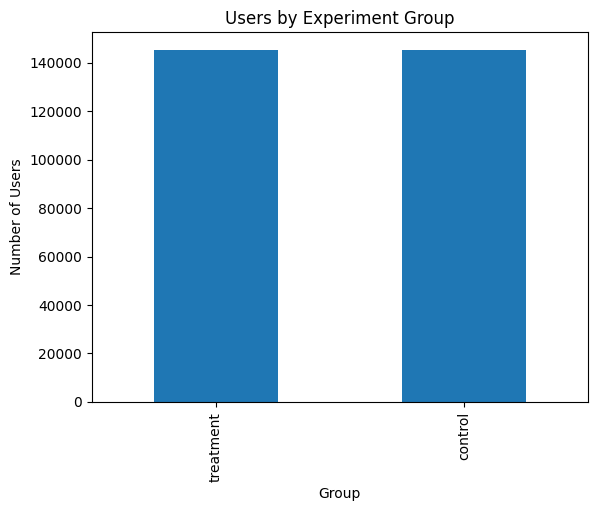

In [20]:
group_counts.plot(kind="bar")

plt.title("Users by Experiment Group")
plt.xlabel("Group")
plt.ylabel("Number of Users")

plt.show()

### Observation

**Observation 1:** The cleaned dataset contains **290,584 unique users**, with **145,310 (50.01%)** assigned to the treatment group and **145,274 (49.99%)** assigned to the control group.

**Observation 2:** The difference between the two groups is only **36 users**, representing **0.01%** of the experiment population. This indicates that user allocation was effectively balanced across both experiment groups.

**Business Implication:** Since both groups contain nearly the same number of users, any observed difference in conversion rates is less likely to be influenced by unequal traffic allocation and can be compared with greater confidence.

### Overall Conversion Rate

Before comparing the two experiment groups, calculate the overall conversion rate across all users.

This provides a baseline that helps interpret the performance of each landing page.

In [21]:
overall_conversion = df_clean["converted"].mean()

print(f"Overall Conversion Rate: {overall_conversion:.4%}")

Overall Conversion Rate: 11.9597%


In [22]:
converted_users = df_clean["converted"].sum()

total_users = len(df_clean)

print("Converted Users :", converted_users)
print("Total Users :", total_users)

Converted Users : 34753
Total Users : 290584


**Observation:** The cleaned experiment contains **290,584 users**, of which **34,753** completed the desired action. This results in an overall conversion rate of **11.96%**, providing the baseline against which the control and treatment groups will be compared.

### Conversion Rate by Experiment Group

The primary objective of the experiment is to determine whether the new landing page changes the conversion rate.

This section compares the conversion rates of the control and treatment groups.

In [23]:
conversion_summary = (
    df_clean
    .groupby("con_treat")["converted"]
    .agg(["count", "sum", "mean"])
    .rename(columns={
        "count": "Users",
        "sum": "Converted Users",
        "mean": "Conversion Rate"
    })
)

conversion_summary["Conversion Rate"] = (
    conversion_summary["Conversion Rate"] * 100
).round(2)

conversion_summary

,Users,Converted Users,Conversion Rate
con_treat,,,
control,145274,17489,12.04
treatment,145310,17264,11.88


In [24]:
control_conversion_rate = (
    df_clean.loc[df_clean["con_treat"] == "control", "converted"]
    .mean()
)

treatment_conversion_rate = (
    df_clean.loc[df_clean["con_treat"] == "treatment", "converted"]
    .mean()
)

absolute_difference = (
    treatment_conversion_rate - control_conversion_rate
) * 100

print(f"Control Conversion Rate   : {control_conversion_rate:.2%}")
print(f"Treatment Conversion Rate : {treatment_conversion_rate:.2%}")
print(f"Absolute Difference       : {absolute_difference:.2f} percentage points")

Control Conversion Rate   : 12.04%
Treatment Conversion Rate : 11.88%
Absolute Difference       : -0.16 percentage points


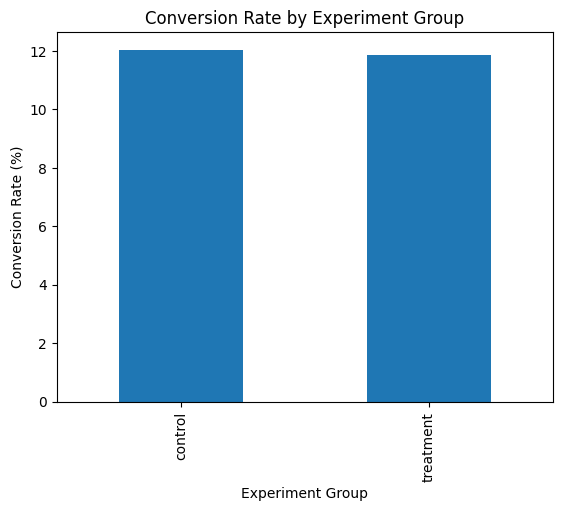

In [25]:
conversion_summary["Conversion Rate"].plot(kind="bar")

plt.title("Conversion Rate by Experiment Group")
plt.xlabel("Experiment Group")
plt.ylabel("Conversion Rate (%)")

plt.show()

### Observation

**Observation:** The control group achieved a conversion rate of **12.04%**, while the treatment group achieved **11.88%**. This corresponds to an **absolute difference of -0.16 percentage points**, indicating that the new landing page performed slightly worse than the existing landing page in the observed sample.

**Business Implication:** Although the observed conversion rate is lower for the treatment group, statistical testing is required to determine whether this difference is statistically significant or could have occurred by chance.

## A/B Test Analysis

The observed difference in conversion rates must be evaluated statistically before making a business decision.

The following hypothesis test determines whether the difference between the two landing pages is statistically significant.

### Hypothesis

**Null Hypothesis (H₀):** The new landing page has the same conversion rate as the existing landing page.

**Alternative Hypothesis (H₁):** The new landing page has a different conversion rate from the existing landing page.

**Note:** We're using a two-sided test because the business question is whether the new page performs differently, not specifically better. This is a more neutral assumption unless the experiment was explicitly designed as a one-sided test.

In [26]:
from statsmodels.stats.proportion import proportions_ztest

In [28]:
converted = [
    conversion_summary.loc["control", "Converted Users"],
    conversion_summary.loc["treatment", "Converted Users"]
]

visitors = [
    conversion_summary.loc["control", "Users"],
    conversion_summary.loc["treatment", "Users"]
]

z_statistic, p_value = proportions_ztest(
    count=converted,
    nobs=visitors
)

print(f"Z Statistic : {z_statistic:.4f}")
print(f"P Value     : {p_value:.4f}")

Z Statistic : 1.3109
P Value     : 0.1899


**Observation:** The hypothesis test produced a **p-value of 0.1899** (>0.05), which is greater than the commonly used significance level of **0.05**.

**Business Implication:** The observed difference in conversion rates is **not statistically significant**. Based on the available experiment data, there is insufficient evidence to conclude that the new landing page performs differently from the existing landing page.

### Confidence Interval

A confidence interval estimates the range within which the true difference in conversion rates is likely to lie.

This helps assess the practical impact of the new landing page, even when the hypothesis test is not statistically significant.

In [29]:
from statsmodels.stats.proportion import confint_proportions_2indep

In [30]:
lower, upper = confint_proportions_2indep(
    count1=conversion_summary.loc["treatment", "Converted Users"],
    nobs1=conversion_summary.loc["treatment", "Users"],
    count2=conversion_summary.loc["control", "Converted Users"],
    nobs2=conversion_summary.loc["control", "Users"],
    method="wald"
)

print(f"95% Confidence Interval: ({lower:.4%}, {upper:.4%})")

95% Confidence Interval: (-0.3938%, 0.0781%)


**Observation:** The **95% confidence interval ranges from -0.39% to 0.08%**. Since the interval includes **0%**, the true difference in conversion rates could be slightly negative, slightly positive, or there may be no meaningful difference at all.

**Business Implication:** The experiment does not provide sufficient evidence to conclude that the new landing page improves conversion. Any observed difference is likely to be too small to justify a full rollout based on the current data.

## Business Recommendation

The objective of this analysis was to determine whether the new landing page should replace the existing landing page based on user conversion.

The recommendation below is based on the complete experiment analysis.

In [31]:
summary = pd.DataFrame({
    "Metric": [
        "Control Conversion Rate",
        "Treatment Conversion Rate",
        "Absolute Difference",
        "P Value"
    ],
    "Value": [
        f"{control_conversion_rate:.2%}",
        f"{treatment_conversion_rate:.2%}",
        f"{absolute_difference:.2f} percentage points",
        f"{p_value:.4f}"
    ]
})

summary

,Metric,Value
0,Control Conversion Rate,12.04%
1,Treatment Conversion Rate,11.88%
2,Absolute Difference,-0.16 percentage points
3,P Value,0.1899


# Executive Summary

## Business Objective

Evaluate whether the new landing page improves user conversion compared with the existing landing page.

## Key Findings

| Metric | Result |
|---------|---------|
| Control Conversion Rate | **12.04%** |
| Treatment Conversion Rate | **11.88%** |
| Absolute Difference | **-0.16 percentage points** |
| P Value | **0.1899** |
| 95% Confidence Interval | **-0.39% to 0.08%** |

## Recommendation

The analysis does not provide sufficient statistical evidence that the new landing page improves user conversion.

Although the observed conversion rate of the treatment page is slightly lower than the control page, the difference is not statistically significant and the confidence interval includes zero.

Based on the current experiment, the existing landing page should continue to be used.

## Business Impact

Rolling out the new landing page would introduce implementation effort without demonstrating a measurable improvement in conversion.

Maintaining the existing landing page minimizes unnecessary product changes while additional improvements to the new page are evaluated before a future experiment.